# U-Net Baseline: Patch-Based Training, Tuning, and Final Evaluation

Trains a patch-based U-Net baseline, tunes key hyperparameters with Optuna, then runs a final training on full rasters. Exports reproducible splits, metrics, and meeting-ready plots.

In [28]:
from dataclasses import dataclass
from pathlib import Path
import rasterio
from rasterio.windows import Window

import numpy as np
from typing import Union, Tuple, Dict, Sequence, Optional
import random

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp

import optuna
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Polygon, Rectangle
from matplotlib.collections import PatchCollection

## Experiment Setup

Defines dataset paths, nodata rules, class setup, normalisation method, patch/stride choices, and runtime settings used throughout the notebook.

### Experiment Configuration

In [2]:
# Input files
img_path = "../../data/inputs/map/map_test.tif"
lbl_path = "../../data/inputs/label/label_test.tif"

# Task
num_classes = 3
label_values = [0, 1, 2]

# Nodata handling
nodata_value = -9999
ignore_index = -9999

# Input data
in_channels = 6
bands = ["R", "G", "B", "NIR", "SWIR1", "SWIR2"]

# Normalisation
normalisation = "per_band_mean_std"  # computed on TRAIN patches only

# Patching
patch_size = 256
stride_train = 256
stride_infer = 128

In [3]:
PATCH_SIZES = [128, 256, 512]
BLOCK_SIZES = [2048, 4096]

def stride_train_from_patch(p):  # your rule
    return p

def stride_infer_from_patch(p):  # your rule
    return p // 2

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- DataLoader / runtime settings (global) ---
BATCH_SIZE = 8
NUM_WORKERS = 0                  # recommended with rasterio windows
PIN_MEMORY = (device.type == "cuda")

ratios = (0.70, 0.15, 0.15)
seed = 42

FIXED_ENCODER = "resnet34"
FIXED_LR = 1e-3
FIXED_WEIGHT_DECAY = 1e-4

Using device: cuda


### Patch Grid Construction (Rasterio Windows)

Creates a deterministic patch index over the raster using rasterio windows, including edge-coverage logic to avoid missing border areas.

In [5]:
@dataclass(frozen=True)
class PatchSpec:
    row_off: int
    col_off: int
    height: int
    width: int

def build_patch_index(
    img_path: Union[str, Path],
    lbl_path: Union[str, Path],
    patch_size: int = 256,
    stride: int = 256,
):
    img_path = Path(img_path)
    lbl_path = Path(lbl_path)

    with rasterio.open(img_path) as img, rasterio.open(lbl_path) as lbl:
        assert img.width == lbl.width and img.height == lbl.height, "Shape mismatch"
        assert img.transform == lbl.transform, "Transform mismatch"
        assert img.crs == lbl.crs, "CRS mismatch"

        H, W = img.height, img.width

        patches = []
        for row_off in range(0, H - patch_size + 1, stride):
            for col_off in range(0, W - patch_size + 1, stride):
                patches.append(PatchSpec(row_off, col_off, patch_size, patch_size))

        # edge coverage
        if (H - patch_size) % stride != 0:
            row_off = H - patch_size
            for col_off in range(0, W - patch_size + 1, stride):
                patches.append(PatchSpec(row_off, col_off, patch_size, patch_size))
        if (W - patch_size) % stride != 0:
            col_off = W - patch_size
            for row_off in range(0, H - patch_size + 1, stride):
                patches.append(PatchSpec(row_off, col_off, patch_size, patch_size))
        if (H - patch_size) % stride != 0 and (W - patch_size) % stride != 0:
            patches.append(PatchSpec(H - patch_size, W - patch_size, patch_size, patch_size))

    return patches

### Spatial Block Split (Train/Val/Test)

Splits patches by coarse spatial blocks to reduce spatial leakage, ensuring train/val/test are separated geographically.

In [6]:
def assign_block_id(p: PatchSpec, block_size: int) -> Tuple[int, int]:
    """
    Assign a coarse spatial block ID based on the patch's top-left pixel.
    """
    block_row = p.row_off // block_size
    block_col = p.col_off // block_size
    return (block_row, block_col)

def spatial_block_split(
    patches: Sequence[PatchSpec],
    block_size: int,
    ratios=(0.70, 0.15, 0.15),
    seed: int = 42,
):
    assert abs(sum(ratios) - 1.0) < 1e-6, "ratios must sum to 1"

    # group patches by block
    block_to_patches: Dict[Tuple[int, int], list] = {}
    for p in patches:
        bid = assign_block_id(p, block_size)
        block_to_patches.setdefault(bid, []).append(p)

    block_ids = list(block_to_patches.keys())
    rng = random.Random(seed)
    rng.shuffle(block_ids)

    n = len(block_ids)
    n_train = int(ratios[0] * n)
    n_val = int(ratios[1] * n)

    train_blocks = set(block_ids[:n_train])
    val_blocks = set(block_ids[n_train:n_train + n_val])
    test_blocks = set(block_ids[n_train + n_val:])

    train = [p for bid in train_blocks for p in block_to_patches[bid]]
    val   = [p for bid in val_blocks for p in block_to_patches[bid]]
    test  = [p for bid in test_blocks for p in block_to_patches[bid]]

    return train, val, test, train_blocks, val_blocks, test_blocks

In [7]:
def has_any_valid_label(lbl_path, p: PatchSpec, ignore_index=-9999) -> bool:
    with rasterio.open(lbl_path) as lbl:
        w = Window(p.col_off, p.row_off, p.width, p.height)
        y = lbl.read(1, window=w)
    return np.any(y != ignore_index)

def filter_all_ignore_patches(lbl_path, patch_list, ignore_index=-9999):
    return [p for p in patch_list if has_any_valid_label(lbl_path, p, ignore_index=ignore_index)]


In [8]:
def estimate_mean_std(
    img_path,
    patch_list,
    nodata_value=-9999,
    max_patches=200,
    seed=42,
):
    rng = np.random.default_rng(seed)
    n = min(max_patches, len(patch_list))
    sample = rng.choice(patch_list, size=n, replace=False)

    sums = None
    sumsqs = None
    counts = None

    with rasterio.open(img_path) as img:
        for p in sample:
            w = Window(p.col_off, p.row_off, p.width, p.height)
            x = img.read(window=w).astype(np.float32)  # [C,H,W]

            valid = x != nodata_value  # [C,H,W]

            if sums is None:
                C = x.shape[0]
                sums = np.zeros(C, dtype=np.float64)
                sumsqs = np.zeros(C, dtype=np.float64)
                counts = np.zeros(C, dtype=np.int64)

            for c in range(x.shape[0]):
                vc = valid[c]
                vals = x[c][vc]
                counts[c] += vals.size
                if vals.size > 0:
                    sums[c] += vals.sum(dtype=np.float64)
                    sumsqs[c] += (vals.astype(np.float64) ** 2).sum(dtype=np.float64)

    mean = sums / np.maximum(counts, 1)
    var = (sumsqs / np.maximum(counts, 1)) - mean**2
    std = np.sqrt(np.maximum(var, 1e-12))

    return mean.astype(np.float32), std.astype(np.float32)


### Dataset: On-the-Fly Raster Window Sampling

Loads image/label windows lazily per patch, applies train-only normalisation, and returns tensors ready for PyTorch training.

In [9]:
class RasterPatchDataset(Dataset):
    def __init__(
        self,
        img_path: str,
        lbl_path: str,
        patches: Sequence[PatchSpec],
        num_classes: int = 3,
        nodata_value: int = -9999,
        ignore_index: int = -9999,
        mean: Optional[np.ndarray] = None,
        std: Optional[np.ndarray] = None,
    ):
        self.img_path = str(img_path)
        self.lbl_path = str(lbl_path)
        self.patches = list(patches)

        self.num_classes = num_classes
        self.nodata_value = nodata_value
        self.ignore_index = ignore_index

        self.mean = None if mean is None else mean.reshape(-1, 1, 1)
        self.std  = None if std  is None else std.reshape(-1, 1, 1)

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        p = self.patches[idx]
        w = Window(p.col_off, p.row_off, p.width, p.height)

        with rasterio.open(self.img_path) as img, rasterio.open(self.lbl_path) as lbl:
            x = img.read(window=w).astype(np.float32)      # [C,H,W]
            y = lbl.read(1, window=w).astype(np.int64)     # [H,W]

        # Normalise only valid pixels (not nodata)
        if self.mean is not None and self.std is not None:
            valid = (x != self.nodata_value)
            x_norm = (x - self.mean) / self.std
            x = np.where(valid, x_norm, 0.0).astype(np.float32)  # set nodata to 0 after norm

        # Convert to torch
        x_t = torch.from_numpy(x)                 # float32 [C,H,W]
        y_t = torch.from_numpy(y)                 # int64   [H,W]

        return x_t, y_t

### Metric: Mean IoU (Ignore Nodata)

In [10]:
@torch.no_grad()
def mean_iou(pred_logits, y_true, num_classes=3, ignore_index=-9999):
    """
    pred_logits: [B, C, H, W]
    y_true:      [B, H, W]
    """
    preds = torch.argmax(pred_logits, dim=1)  # [B,H,W]

    ious = []
    for cls in range(num_classes):
        pred_mask = (preds == cls)
        true_mask = (y_true == cls)

        valid = (y_true != ignore_index)
        pred_mask = pred_mask & valid
        true_mask = true_mask & valid

        intersection = (pred_mask & true_mask).sum().item()
        union = (pred_mask | true_mask).sum().item()

        if union == 0:
            continue  # skip class not present in this batch
        ious.append(intersection / union)

    if len(ious) == 0:
        return float("nan")
    return float(np.mean(ious))

### Training Loop: One Epoch Train + Validate

Implements one epoch of training and validation, tracking loss and IoU for convergence monitoring and later plotting.

In [11]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_iou = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)                 # [B, 3, H, W]
        loss = criterion(logits, y)       # y: [B, H, W]
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        running_iou.append(mean_iou(logits, y, num_classes=3, ignore_index=-9999))

    epoch_loss = running_loss / len(loader.dataset)
    epoch_iou = float(np.nanmean(running_iou))
    return epoch_loss, epoch_iou


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_iou = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)
        running_iou.append(mean_iou(logits, y, num_classes=3, ignore_index=-9999))

    epoch_loss = running_loss / len(loader.dataset)
    epoch_iou = float(np.nanmean(running_iou))
    return epoch_loss, epoch_iou

## Baseline Experiments
### Data Pipelines: Build Splits, Normalisation, and Loaders

In [12]:
def make_loaders(
    img_path: str,
    lbl_path: str,
    patch_size: int,
    stride_train: int,
    block_size: int,
    ratios=(0.70, 0.15, 0.15),
    seed: int = 42,
):

    # 1) build patch grid for THIS patch_size/stride_train
    patches = build_patch_index(
        img_path, lbl_path,
        patch_size=patch_size,
        stride=stride_train
    )

    # 2) split by blocks
    train_patches, val_patches, test_patches, train_blocks, val_blocks, test_blocks = spatial_block_split(
        patches,
        block_size=block_size,
        ratios=ratios,
        seed=seed,
    )

    # 3) filter empty-label
    train_patches = filter_all_ignore_patches(lbl_path, train_patches, ignore_index=ignore_index)
    val_patches   = filter_all_ignore_patches(lbl_path, val_patches,   ignore_index=ignore_index)
    test_patches  = filter_all_ignore_patches(lbl_path, test_patches,  ignore_index=ignore_index)

    # 4) train-only mean/std
    train_mean, train_std = estimate_mean_std(
        img_path,
        train_patches,
        nodata_value=nodata_value,
        max_patches=200,
        seed=seed,
    )

    # 5) datasets
    train_ds = RasterPatchDataset(img_path, lbl_path, train_patches,
                                  num_classes=num_classes,
                                  nodata_value=nodata_value,
                                  ignore_index=ignore_index,
                                  mean=train_mean, std=train_std)
    val_ds   = RasterPatchDataset(img_path, lbl_path, val_patches,
                                  num_classes=num_classes,
                                  nodata_value=nodata_value,
                                  ignore_index=ignore_index,
                                  mean=train_mean, std=train_std)
    test_ds  = RasterPatchDataset(img_path, lbl_path, test_patches,
                                  num_classes=num_classes,
                                  nodata_value=nodata_value,
                                  ignore_index=ignore_index,
                                  mean=train_mean, std=train_std)

    # 6) loaders
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)


    info = {
        "patch_size": patch_size,
        "stride_train": stride_train,
        "stride_infer": stride_infer_from_patch(patch_size),  # for reporting only
        "block_size": block_size,
        "n_patches_total": len(patches),
        "n_train": len(train_ds),
        "n_val": len(val_ds),
        "n_test": len(test_ds),
        "train_blocks": len(train_blocks),
        "val_blocks": len(val_blocks),
        "test_blocks": len(test_blocks),
    }
    return train_loader, val_loader, test_loader, info

### Optuna Objective: Evaluate a Fixed Data Split

In [13]:
def build_model():
    return smp.Unet(
        encoder_name=FIXED_ENCODER,
        encoder_weights=None,
        in_channels=in_channels,
        classes=num_classes,
    )


def make_objective(train_loader, val_loader, n_epochs=10):
    def objective(trial: optuna.Trial):

        model = build_model().to(device)

        criterion = nn.CrossEntropyLoss(ignore_index=ignore_index)
        optimizer = optim.AdamW(
            model.parameters(),
            lr=FIXED_LR,
            weight_decay=FIXED_WEIGHT_DECAY,
        )

        val_ious = []

        for epoch in range(1, n_epochs + 1):
            train_one_epoch(model, train_loader, optimizer, criterion, device)
            _, val_iou = validate_one_epoch(model, val_loader, criterion, device)

            trial.report(val_iou, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

            val_ious.append(val_iou)

        return float(np.mean(val_ious[-3:]))  # stable tail mean

    return objective

### Baseline Study: Compare Patch Size × Block Size

In [14]:
results = []

for p in PATCH_SIZES:
    s_train = stride_train_from_patch(p)

    for bs in BLOCK_SIZES:
        train_loader, val_loader, test_loader, info = make_loaders(
            img_path=img_path,
            lbl_path=lbl_path,
            patch_size=p,
            stride_train=s_train,
            block_size=bs,
            ratios=ratios,
            seed=seed,
        )

        study_name = f"unet_p{p}_s{s_train}_b{bs}"

        study = optuna.create_study(
            direction="maximize",
            storage="sqlite:///optuna_unet.db",
            study_name=study_name,
            load_if_exists=True,
        )

        objective = make_objective(train_loader, val_loader, n_epochs=10)
        study.optimize(objective, n_trials=5)

        results.append({
            **info,
            "study_name": study_name,
            "best_val_mIoU": study.best_value,
        })

df = pd.DataFrame(results).sort_values("best_val_mIoU", ascending=False)
df[["patch_size","stride_train","block_size","n_train","n_val","n_test","best_val_mIoU","study_name"]]

[I 2026-01-29 17:08:03,248] A new study created in RDB with name: unet_p128_s128_b2048
[I 2026-01-29 17:59:44,556] Trial 0 finished with value: 0.6732186194031385 and parameters: {}. Best is trial 0 with value: 0.6732186194031385.
[I 2026-01-29 18:54:06,469] Trial 1 finished with value: 0.6634371887184899 and parameters: {}. Best is trial 0 with value: 0.6732186194031385.
[I 2026-01-29 19:47:13,013] Trial 2 finished with value: 0.6721530309310203 and parameters: {}. Best is trial 0 with value: 0.6732186194031385.
[I 2026-01-29 20:39:36,998] Trial 3 finished with value: 0.6697595632615091 and parameters: {}. Best is trial 0 with value: 0.6732186194031385.
[I 2026-01-29 21:34:50,419] Trial 4 finished with value: 0.6474313491434872 and parameters: {}. Best is trial 0 with value: 0.6732186194031385.
[I 2026-01-29 21:35:36,406] A new study created in RDB with name: unet_p128_s128_b4096
[I 2026-01-29 22:26:12,832] Trial 0 finished with value: 0.5922299994579124 and parameters: {}. Best is tr

,patch_size,stride_train,block_size,n_train,n_val,n_test,best_val_mIoU,study_name
2,256,256,2048,2012,432,520,0.676638,unet_p256_s256_b2048
0,128,128,2048,8432,1920,1504,0.673219,unet_p128_s128_b2048
4,512,512,2048,510,112,132,0.643022,unet_p512_s512_b2048
3,256,256,4096,2128,292,544,0.615387,unet_p256_s256_b4096
5,512,512,4096,536,74,144,0.614652,unet_p512_s512_b4096
1,128,128,4096,8512,1168,2176,0.613796,unet_p128_s128_b4096


In [16]:
df = df.sort_values(by='best_val_mIoU', ascending=False)
df

,patch_size,stride_train,stride_infer,block_size,n_patches_total,n_train,n_val,n_test,train_blocks,val_blocks,test_blocks,study_name,best_val_mIoU
2,256,256,128,2048,2964,2012,432,520,34,7,8,unet_p256_s256_b2048,0.676638
0,128,128,64,2048,11856,8432,1920,1504,39,8,9,unet_p128_s128_b2048,0.673219
4,512,512,256,2048,754,510,112,132,34,7,8,unet_p512_s512_b2048,0.643022
3,256,256,128,4096,2964,2128,292,544,11,2,3,unet_p256_s256_b4096,0.615387
5,512,512,256,4096,754,536,74,144,11,2,3,unet_p512_s512_b4096,0.614652
1,128,128,64,4096,11856,8512,1168,2176,11,2,3,unet_p128_s128_b4096,0.613796


In [20]:
df.to_csv('../../data/outputs/baseline/block_size_comparision.csv', index=False)

## Optuna Tuning With Augmentation and Early Stopping
### Dataset Extension: Lightweight Augmentation Controls

In [14]:
class RasterPatchDataset(Dataset):
    def __init__(
        self,
        img_path: str,
        lbl_path: str,
        patches: Sequence[PatchSpec],
        num_classes: int = 3,
        nodata_value: int = -9999,
        ignore_index: int = -9999,
        mean: Optional[np.ndarray] = None,
        std: Optional[np.ndarray] = None,
        augment: bool = False,
        aug_prob: float = 0.0,
        noise_std: float = 0.0,
        seed: int = 42,
    ):
        self.img_path = str(img_path)
        self.lbl_path = str(lbl_path)
        self.patches = list(patches)

        self.num_classes = num_classes
        self.nodata_value = nodata_value
        self.ignore_index = ignore_index

        self.mean = None if mean is None else mean.reshape(-1, 1, 1)
        self.std  = None if std  is None else std.reshape(-1, 1, 1)

        self.augment = augment
        self.aug_prob = float(aug_prob)
        self.noise_std = float(noise_std)
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.patches)

    def _augment(self, x: np.ndarray, y: np.ndarray):
        if self.rng.random() > self.aug_prob:
            return x, y

        # horizontal flip
        if self.rng.random() < 0.5:
            x = x[:, :, ::-1].copy()
            y = y[:, ::-1].copy()

        # vertical flip
        if self.rng.random() < 0.5:
            x = x[:, ::-1, :].copy()
            y = y[::-1, :].copy()

        # rotate 0/90/180/270
        k = int(self.rng.integers(0, 4))
        if k:
            x = np.rot90(x, k=k, axes=(1, 2)).copy()
            y = np.rot90(y, k=k, axes=(0, 1)).copy()

        # additive gaussian noise on valid pixels
        if self.noise_std > 0:
            noise = self.rng.normal(0.0, self.noise_std, size=x.shape).astype(np.float32)
            valid = (x != self.nodata_value)
            x = np.where(valid, x + noise, x).astype(np.float32)

        return x, y

    def __getitem__(self, idx):
        p = self.patches[idx]
        w = Window(p.col_off, p.row_off, p.width, p.height)

        with rasterio.open(self.img_path) as img, rasterio.open(self.lbl_path) as lbl:
            x = img.read(window=w).astype(np.float32)      # [C,H,W]
            y = lbl.read(1, window=w).astype(np.int64)     # [H,W]

        if self.augment:
            x, y = self._augment(x, y)

        if self.mean is not None and self.std is not None:
            valid = (x != self.nodata_value)
            x_norm = (x - self.mean) / self.std
            x = np.where(valid, x_norm, 0.0).astype(np.float32)

        x_t = torch.from_numpy(x)
        y_t = torch.from_numpy(y)

        return x_t, y_t

### Loss Prep: Estimate Class Frequencies

In [15]:
def estimate_class_freqs(
    lbl_path: str,
    patch_list: Sequence[PatchSpec],
    num_classes: int,
    ignore_index: int = -9999,
    max_patches: int = 200,
    seed: int = 42,
):
    rng = np.random.default_rng(seed)
    n = min(max_patches, len(patch_list))
    sample = rng.choice(patch_list, size=n, replace=False)

    counts = np.zeros(num_classes, dtype=np.int64)

    with rasterio.open(lbl_path) as lbl:
        for p in sample:
            w = Window(p.col_off, p.row_off, p.width, p.height)
            y = lbl.read(1, window=w)

            mask = (y != ignore_index)
            yv = y[mask]
            if yv.size == 0:
                continue

            for c in range(num_classes):
                counts[c] += np.sum(yv == c)

    total = max(int(counts.sum()), 1)
    freqs = counts / total
    freqs = np.clip(freqs, 1e-8, 1.0).astype(np.float32)
    return freqs

### Data API Update: Return Datasets and Train Patch List

In [16]:
def make_datasets(
    img_path: str,
    lbl_path: str,
    patch_size: int,
    stride_train: int,
    block_size: int,
    ratios=(0.70, 0.15, 0.15),
    seed: int = 42,
):
    patches = build_patch_index(img_path, lbl_path, patch_size=patch_size, stride=stride_train)

    train_patches, val_patches, test_patches, train_blocks, val_blocks, test_blocks = spatial_block_split(
        patches, block_size=block_size, ratios=ratios, seed=seed
    )

    train_patches = filter_all_ignore_patches(lbl_path, train_patches, ignore_index=ignore_index)
    val_patches   = filter_all_ignore_patches(lbl_path, val_patches,   ignore_index=ignore_index)
    test_patches  = filter_all_ignore_patches(lbl_path, test_patches,  ignore_index=ignore_index)

    train_mean, train_std = estimate_mean_std(
        img_path, train_patches, nodata_value=nodata_value, max_patches=200, seed=seed
    )

    train_ds = RasterPatchDataset(
        img_path, lbl_path, train_patches,
        num_classes=num_classes, nodata_value=nodata_value, ignore_index=ignore_index,
        mean=train_mean, std=train_std,
        augment=False, aug_prob=0.0, noise_std=0.0, seed=seed
    )
    val_ds = RasterPatchDataset(
        img_path, lbl_path, val_patches,
        num_classes=num_classes, nodata_value=nodata_value, ignore_index=ignore_index,
        mean=train_mean, std=train_std,
        augment=False
    )
    test_ds = RasterPatchDataset(
        img_path, lbl_path, test_patches,
        num_classes=num_classes, nodata_value=nodata_value, ignore_index=ignore_index,
        mean=train_mean, std=train_std,
        augment=False
    )

    info = {
        "patch_size": patch_size,
        "stride_train": stride_train,
        "stride_infer": stride_infer_from_patch(patch_size),
        "block_size": block_size,
        "n_patches_total": len(patches),
        "n_train": len(train_ds),
        "n_val": len(val_ds),
        "n_test": len(test_ds),
        "train_blocks": len(train_blocks),
        "val_blocks": len(val_blocks),
        "test_blocks": len(test_blocks),
    }
    return train_ds, val_ds, test_ds, train_patches, info

### Optuna Objective: Tune LR/WD/Batch/Aug/Weights with Early Stopping

In [17]:
def make_objective(
    train_ds,
    val_ds,
    train_patches,
    n_epochs_max: int = 30,
):
    # compute train class frequencies once for this fixed split
    freqs = estimate_class_freqs(
        lbl_path=lbl_path,
        patch_list=train_patches,
        num_classes=num_classes,
        ignore_index=ignore_index,
        max_patches=200,
        seed=seed,
    )

    def objective(trial: optuna.Trial):
        # ---- tune lr & weight decay ----
        lr = trial.suggest_float("lr", 1e-5, 3e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

        # ---- tune batch size ----
        batch_size = trial.suggest_categorical("batch_size", [4, 8, 16])

        # ---- tune loss weighting (beta=0 => uniform, beta=1 => inverse freq) ----
        beta = trial.suggest_float("class_weight_beta", 0.0, 1.0)
        w = (1.0 / freqs) ** beta
        w = w / np.mean(w)
        w_t = torch.tensor(w, dtype=torch.float32, device=device)

        # ---- tune augmentation strength ----
        aug_prob  = trial.suggest_float("aug_prob", 0.0, 0.8)
        noise_std = trial.suggest_float("noise_std", 0.0, 0.10)

        train_ds.augment = (aug_prob > 0.0 or noise_std > 0.0)
        train_ds.aug_prob = float(aug_prob)
        train_ds.noise_std = float(noise_std)

        # ---- epoch budget + early stopping ----
        max_epochs = trial.suggest_int("max_epochs", 10, n_epochs_max)
        patience = trial.suggest_int("patience", 3, 8)

        # loaders depend on batch size
        train_loader = DataLoader(
            train_ds, batch_size=batch_size, shuffle=True,
            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
        )
        val_loader = DataLoader(
            val_ds, batch_size=batch_size, shuffle=False,
            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
        )

        model = build_model().to(device)
        criterion = nn.CrossEntropyLoss(ignore_index=ignore_index, weight=w_t)
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

        best_val = -1.0
        no_improve = 0

        try:
            for epoch in range(1, max_epochs + 1):
                train_one_epoch(model, train_loader, optimizer, criterion, device)
                _, val_iou = validate_one_epoch(model, val_loader, criterion, device)

                trial.report(val_iou, step=epoch)
                if trial.should_prune():
                    raise optuna.TrialPruned()

                if np.isfinite(val_iou) and val_iou > best_val + 1e-4:
                    best_val = float(val_iou)
                    no_improve = 0
                else:
                    no_improve += 1

                if no_improve >= patience:
                    break

        except RuntimeError as e:
            # auto-prune OOM trials
            if "out of memory" in str(e).lower():
                raise optuna.TrialPruned()
            raise

        return best_val

    return objective

### Optuna Run: Fixed Spatial Design (p256, b2048, ResNet34)

Runs hyperparameter search (Stage A) and confirmation (Stage B) for a fixed spatial design, then locks best params for final training.

In [18]:
# Fixed choices
patch_size = 256
block_size = 2048
stride_train = 256

### Stage A Setup: Build Datasets and Define Study Name

In [23]:
train_ds, val_ds, test_ds, train_patches, info = make_datasets(
    img_path=img_path,
    lbl_path=lbl_path,
    patch_size=patch_size,
    stride_train=stride_train,
    block_size=block_size,
    ratios=ratios,
    seed=seed,
)

study_name = f"unet_resnet34_p{patch_size}_b{block_size}"
print(info)

{'patch_size': 256, 'stride_train': 256, 'stride_infer': 128, 'block_size': 2048, 'n_patches_total': 2964, 'n_train': 2012, 'n_val': 432, 'n_test': 520, 'train_blocks': 34, 'val_blocks': 7, 'test_blocks': 8}


### Stage A: Cheap Hyperparameter Search

In [25]:
N_EPOCHS_MAX_A = 15     # 12–15
N_TRIALS_A = 40         # 30–60
STUDY_NAME_A = f"{study_name}_stageA"

study_A = optuna.create_study(
    direction="maximize",
    storage="sqlite:///optuna_unet.db",
    study_name=STUDY_NAME_A,
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2, interval_steps=1),
)

objective_A = make_objective(train_ds, val_ds, train_patches, n_epochs_max=N_EPOCHS_MAX_A)
study_A.optimize(objective_A, n_trials=N_TRIALS_A)

print("Stage A best mIoU:", study_A.best_value)
print("Stage A best params:", study_A.best_params)

df_A = study_A.trials_dataframe().sort_values("value", ascending=False)
df_A.head(10)

[I 2026-01-30 22:34:57,758] A new study created in RDB with name: unet_resnet34_p256_b2048_stageA
[I 2026-01-30 22:57:53,669] Trial 0 finished with value: 0.6397714914990928 and parameters: {'lr': 0.0005847321668906866, 'weight_decay': 0.0024615750295409545, 'batch_size': 8, 'class_weight_beta': 0.7200028056526641, 'aug_prob': 0.13391591932697766, 'noise_std': 0.010481085699436489, 'max_epochs': 12, 'patience': 7}. Best is trial 0 with value: 0.6397714914990928.
[I 2026-01-30 23:28:12,802] Trial 1 finished with value: 0.6666869878327121 and parameters: {'lr': 0.000625869902709649, 'weight_decay': 4.838214955711386e-06, 'batch_size': 8, 'class_weight_beta': 0.045559483953749536, 'aug_prob': 0.5009174355946747, 'noise_std': 0.09607000208307043, 'max_epochs': 15, 'patience': 7}. Best is trial 1 with value: 0.6666869878327121.
[I 2026-01-30 23:48:15,675] Trial 2 finished with value: 0.6072787768054504 and parameters: {'lr': 0.0021618915783851635, 'weight_decay': 9.168599563495867e-06, 'bat

Stage A best mIoU: 0.704985886970943
Stage A best params: {'aug_prob': 0.12562971280939628, 'batch_size': 4, 'class_weight_beta': 0.11181393929930035, 'lr': 0.00028418488699866537, 'max_epochs': 13, 'noise_std': 0.06613831866358576, 'patience': 4, 'weight_decay': 0.0007251289190865493}


,number,value,datetime_start,datetime_complete,duration,params_aug_prob,params_batch_size,params_class_weight_beta,params_lr,params_max_epochs,params_noise_std,params_patience,params_weight_decay,state
21,21,0.704986,2026-01-31 05:19:38.848928,2026-01-31 05:48:37.677083,0 days 00:28:58.828155,0.125630,4,0.111814,0.000284,13,0.066138,4,0.000725,COMPLETE
22,22,0.700939,2026-01-31 05:48:37.890564,2026-01-31 06:16:47.085376,0 days 00:28:09.194812,0.006863,4,0.002178,0.000208,13,0.068788,3,0.000937,COMPLETE
23,23,0.699246,2026-01-31 06:16:47.292968,2026-01-31 06:45:35.011023,0 days 00:28:47.718055,0.096223,4,0.122278,0.000204,13,0.070111,5,0.001132,COMPLETE
33,33,0.694793,2026-01-31 08:43:45.020646,2026-01-31 09:11:03.212205,0 days 00:27:18.191559,0.230711,4,0.205623,0.000116,12,0.074686,8,0.000478,COMPLETE
24,24,0.686718,2026-01-31 06:45:35.215384,2026-01-31 07:12:28.148746,0 days 00:26:52.933362,0.113388,4,0.118317,0.000256,12,0.070701,6,0.000912,COMPLETE
32,32,0.686186,2026-01-31 08:14:09.606255,2026-01-31 08:43:44.805680,0 days 00:29:35.199425,0.113323,4,0.094782,0.000440,13,0.066077,5,0.000882,COMPLETE
15,15,0.686179,2026-01-31 03:51:59.853103,2026-01-31 04:20:32.362402,0 days 00:28:32.509299,0.007736,4,0.006223,0.000066,13,0.058456,4,0.000604,COMPLETE
10,10,0.685771,2026-01-31 02:06:16.126980,2026-01-31 02:32:46.708348,0 days 00:26:30.581368,0.789078,4,0.020700,0.000086,14,0.037666,3,0.000171,COMPLETE
17,17,0.682964,2026-01-31 04:29:21.468711,2026-01-31 04:58:58.801748,0 days 00:29:37.333037,0.267891,4,0.142509,0.000234,13,0.060901,4,0.000649,COMPLETE
12,12,0.680938,2026-01-31 02:59:15.867094,2026-01-31 03:32:56.382925,0 days 00:33:40.515831,0.770818,4,0.006506,0.000107,14,0.043379,3,0.000353,COMPLETE


### Stage A Output: Save Trial Table

In [26]:
out_a = f"../../data/outputs/baseline/optuna_trials_{STUDY_NAME_A}.csv"
df_A.to_csv(out_a, index=False)
print("Saved:", out_a)

Saved: ../../data/outputs/baseline/optuna_trials_unet_resnet34_p256_b2048_stageA.csv


### Stage B Helper: Retrain a Single Configuration

In [27]:
def run_single_config(
    params: dict,
    train_ds,
    val_ds,
    train_patches,
    n_epochs_max: int = 50,
    seed_run: int = 42,
):
    random.seed(seed_run)
    np.random.seed(seed_run)
    torch.manual_seed(seed_run)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_run)

    freqs = estimate_class_freqs(
        lbl_path=lbl_path,
        patch_list=train_patches,
        num_classes=num_classes,
        ignore_index=ignore_index,
        max_patches=200,
        seed=seed,
    )

    lr = float(params["lr"])
    weight_decay = float(params["weight_decay"])
    batch_size = int(params["batch_size"])
    beta = float(params["class_weight_beta"])
    aug_prob = float(params["aug_prob"])
    noise_std = float(params["noise_std"])
    patience = int(params.get("patience", 5))

    w = (1.0 / freqs) ** beta
    w = w / np.mean(w)
    w_t = torch.tensor(w, dtype=torch.float32, device=device)

    train_ds.augment = (aug_prob > 0.0 or noise_std > 0.0)
    train_ds.aug_prob = aug_prob
    train_ds.noise_std = noise_std
    val_ds.augment = False

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )

    model = build_model().to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=ignore_index, weight=w_t)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val = -1.0
    no_improve = 0

    for epoch in range(1, n_epochs_max + 1):
        train_one_epoch(model, train_loader, optimizer, criterion, device)
        _, val_iou = validate_one_epoch(model, val_loader, criterion, device)

        if np.isfinite(val_iou) and val_iou > best_val + 1e-4:
            best_val = float(val_iou)
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            break

    return best_val

### Stage B: Confirm Top-K Configurations

In [29]:
TOP_K = 8
N_EPOCHS_MAX_B = 50      # 30–60
SEEDS_B = [42]   # use [42] if too slow

df_A_completed = df_A[df_A["state"] == "COMPLETE"].dropna(subset=["value"]).copy()
top = df_A_completed.head(TOP_K)

results = []
for rank, row in enumerate(top.itertuples(index=False), start=1):
    params = {
        "lr": getattr(row, "params_lr"),
        "weight_decay": getattr(row, "params_weight_decay"),
        "batch_size": getattr(row, "params_batch_size"),
        "class_weight_beta": getattr(row, "params_class_weight_beta"),
        "aug_prob": getattr(row, "params_aug_prob"),
        "noise_std": getattr(row, "params_noise_std"),
        "patience": getattr(row, "params_patience"),
    }

    scores = []
    for s in SEEDS_B:
        scores.append(
            run_single_config(
                params=params,
                train_ds=train_ds,
                val_ds=val_ds,
                train_patches=train_patches,
                n_epochs_max=N_EPOCHS_MAX_B,
                seed_run=s,
            )
        )

    results.append({
        "rank_stageA": rank,
        "stageA_value": float(getattr(row, "value")),
        "mean_val_mIoU": float(np.mean(scores)),
        "std_val_mIoU": float(np.std(scores)),
        "seeds": str(SEEDS_B),
        **params,
    })

df_B = pd.DataFrame(results).sort_values("mean_val_mIoU", ascending=False)
df_B

,rank_stageA,stageA_value,mean_val_mIoU,std_val_mIoU,seeds,lr,weight_decay,batch_size,class_weight_beta,aug_prob,noise_std,patience
3,4,0.694793,0.717500,0.0,[42],0.000116,0.000478,4,0.205623,0.230711,0.074686,8
4,5,0.686718,0.709188,0.0,[42],0.000256,0.000912,4,0.118317,0.113388,0.070701,6
1,2,0.700939,0.700021,0.0,[42],0.000208,0.000937,4,0.002178,0.006863,0.068788,3
2,3,0.699246,0.699499,0.0,[42],0.000204,0.001132,4,0.122278,0.096223,0.070111,5
6,7,0.686179,0.685142,0.0,[42],0.000066,0.000604,4,0.006223,0.007736,0.058456,4
7,8,0.685771,0.684921,0.0,[42],0.000086,0.000171,4,0.020700,0.789078,0.037666,3
0,1,0.704986,0.672567,0.0,[42],0.000284,0.000725,4,0.111814,0.125630,0.066138,4
5,6,0.686186,0.668780,0.0,[42],0.000440,0.000882,4,0.094782,0.113323,0.066077,5


### Stage B Output: Save Confirmation Results

In [30]:
out_b = f"../../data/outputs/baseline/optuna_confirm_{study_name}_stageB_top{TOP_K}.csv"
df_B.to_csv(out_b, index=False)
print("Saved:", out_b)

print("\nWinner:")
print(df_B.iloc[0])

Saved: ../../data/outputs/baseline/optuna_confirm_unet_resnet34_p256_b2048_stageB_top8.csv

Winner:
rank_stageA                 4
stageA_value         0.694793
mean_val_mIoU          0.7175
std_val_mIoU              0.0
seeds                    [42]
lr                   0.000116
weight_decay         0.000478
batch_size                  4
class_weight_beta    0.205623
aug_prob             0.230711
noise_std            0.074686
patience                    8
Name: 3, dtype: object


## Final Training on Full Rasters
### Final Run Setup: Full Rasters and Fixed Spatial Design

In [34]:
# === FULL DATA paths (replace with your real files) ===
img_path_full = "../../data/inputs/map/map.tif"
lbl_path_full = "../../data/inputs/label/para_three_class.tif"

# Fixed experimental design choices
patch_size = 256
stride_train = 256
block_size = 2048
ratios = (0.70, 0.15, 0.15)
seed = 42

# Output folder for reusable splits + model + metrics
split_dir = Path("../../data/outputs/splits/unet_resnet34_p256_b2048")
split_dir.mkdir(parents=True, exist_ok=True)

print("Outputs ->", split_dir)

Outputs -> ../../data/outputs/splits/unet_resnet34_p256_b2048


### Reproducible Splits: Export and Reload Patch Lists

In [35]:
def export_patch_specs(patches, csv_path: Path):
    df = pd.DataFrame([{
        "row_off": p.row_off,
        "col_off": p.col_off,
        "height": p.height,
        "width": p.width
    } for p in patches])
    df.to_csv(csv_path, index=False)
    return df

def load_patch_specs(csv_path: Path):
    df = pd.read_csv(csv_path)
    return [PatchSpec(int(r.row_off), int(r.col_off), int(r.height), int(r.width))
            for r in df.itertuples(index=False)]

### Build and Export Spatial Splits (Block-Based)

In [36]:
# 1) Build patch grid on the FULL rasters
patches = build_patch_index(
    img_path_full, lbl_path_full,
    patch_size=patch_size,
    stride=stride_train
)

# 2) Spatial block split
train_patches, val_patches, test_patches, train_blocks, val_blocks, test_blocks = spatial_block_split(
    patches,
    block_size=block_size,
    ratios=ratios,
    seed=seed
)

# 3) Filter patches that are completely ignore_index in labels
train_patches = filter_all_ignore_patches(lbl_path_full, train_patches, ignore_index=ignore_index)
val_patches   = filter_all_ignore_patches(lbl_path_full, val_patches,   ignore_index=ignore_index)
test_patches  = filter_all_ignore_patches(lbl_path_full, test_patches,  ignore_index=ignore_index)

# 4) Export split patch lists (reusable)
train_csv = split_dir / "train_patches.csv"
val_csv   = split_dir / "val_patches.csv"
test_csv  = split_dir / "test_patches.csv"

export_patch_specs(train_patches, train_csv)
export_patch_specs(val_patches,   val_csv)
export_patch_specs(test_patches,  test_csv)

# Optional: export block IDs (for reporting)
pd.DataFrame(sorted(list(train_blocks)), columns=["block_row","block_col"]).to_csv(split_dir/"train_blocks.csv", index=False)
pd.DataFrame(sorted(list(val_blocks)),   columns=["block_row","block_col"]).to_csv(split_dir/"val_blocks.csv",   index=False)
pd.DataFrame(sorted(list(test_blocks)),  columns=["block_row","block_col"]).to_csv(split_dir/"test_blocks.csv",  index=False)

print("Total patches:", len(patches))
print("Train/Val/Test:", len(train_patches), len(val_patches), len(test_patches))
print("Saved splits:", train_csv, val_csv, test_csv)

Total patches: 34587
Train/Val/Test: 15420 3329 3548
Saved splits: ../../data/outputs/splits/unet_resnet34_p256_b2048/train_patches.csv ../../data/outputs/splits/unet_resnet34_p256_b2048/val_patches.csv ../../data/outputs/splits/unet_resnet34_p256_b2048/test_patches.csv


### Normalisation Stats: Compute Train-Only Mean/Std

In [37]:
train_mean, train_std = estimate_mean_std(
    img_path_full,
    train_patches,
    nodata_value=nodata_value,
    max_patches=400,
    seed=seed,
)

np.save(split_dir/"train_mean.npy", train_mean)
np.save(split_dir/"train_std.npy", train_std)

print("Saved mean/std:", split_dir/"train_mean.npy", split_dir/"train_std.npy")

Saved mean/std: ../../data/outputs/splits/unet_resnet34_p256_b2048/train_mean.npy ../../data/outputs/splits/unet_resnet34_p256_b2048/train_std.npy


### Dataset (Final): Augmentation + Train-Only Normalisation

In [38]:
class RasterPatchDataset(Dataset):
    def __init__(
        self,
        img_path: str,
        lbl_path: str,
        patches: Sequence[PatchSpec],
        num_classes: int = 3,
        nodata_value: int = -9999,
        ignore_index: int = -9999,
        mean: Optional[np.ndarray] = None,
        std: Optional[np.ndarray] = None,
        augment: bool = False,
        aug_prob: float = 0.0,
        noise_std: float = 0.0,
        seed: int = 42,
    ):
        self.img_path = str(img_path)
        self.lbl_path = str(lbl_path)
        self.patches = list(patches)

        self.num_classes = num_classes
        self.nodata_value = nodata_value
        self.ignore_index = ignore_index

        self.mean = None if mean is None else mean.reshape(-1, 1, 1)
        self.std  = None if std  is None else std.reshape(-1, 1, 1)

        self.augment = augment
        self.aug_prob = float(aug_prob)
        self.noise_std = float(noise_std)
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.patches)

    def _augment(self, x: np.ndarray, y: np.ndarray):
        if self.rng.random() > self.aug_prob:
            return x, y

        if self.rng.random() < 0.5:  # hflip
            x = x[:, :, ::-1].copy()
            y = y[:, ::-1].copy()

        if self.rng.random() < 0.5:  # vflip
            x = x[:, ::-1, :].copy()
            y = y[::-1, :].copy()

        k = int(self.rng.integers(0, 4))  # rotate 0/90/180/270
        if k:
            x = np.rot90(x, k=k, axes=(1, 2)).copy()
            y = np.rot90(y, k=k, axes=(0, 1)).copy()

        if self.noise_std > 0:
            noise = self.rng.normal(0.0, self.noise_std, size=x.shape).astype(np.float32)
            valid = (x != self.nodata_value)
            x = np.where(valid, x + noise, x).astype(np.float32)

        return x, y

    def __getitem__(self, idx):
        p = self.patches[idx]
        w = Window(p.col_off, p.row_off, p.width, p.height)

        with rasterio.open(self.img_path) as img, rasterio.open(self.lbl_path) as lbl:
            x = img.read(window=w).astype(np.float32)
            y = lbl.read(1, window=w).astype(np.int64)

        if self.augment:
            x, y = self._augment(x, y)

        if self.mean is not None and self.std is not None:
            valid = (x != self.nodata_value)
            x_norm = (x - self.mean) / self.std
            x = np.where(valid, x_norm, 0.0).astype(np.float32)

        return torch.from_numpy(x), torch.from_numpy(y)

### Final Hyperparameters: Lock Best Optuna Configuration

In [39]:
BEST_PARAMS = {
    "lr": 0.000116,
    "weight_decay": 0.000478,
    "batch_size": 4,
    "class_weight_beta": 0.205623,
    "aug_prob": 0.230711,
    "noise_std": 0.074686,
    "patience": 8,
}
MAX_EPOCHS = 50  # fixed upper bound; early stopping controls actual stop

### Final DataLoaders: Train/Val/Test

In [40]:
train_ds = RasterPatchDataset(
    img_path_full, lbl_path_full, train_patches,
    num_classes=num_classes, nodata_value=nodata_value, ignore_index=ignore_index,
    mean=train_mean, std=train_std,
    augment=True, aug_prob=BEST_PARAMS["aug_prob"], noise_std=BEST_PARAMS["noise_std"],
    seed=seed,
)

val_ds = RasterPatchDataset(
    img_path_full, lbl_path_full, val_patches,
    num_classes=num_classes, nodata_value=nodata_value, ignore_index=ignore_index,
    mean=train_mean, std=train_std,
    augment=False,
)

test_ds = RasterPatchDataset(
    img_path_full, lbl_path_full, test_patches,
    num_classes=num_classes, nodata_value=nodata_value, ignore_index=ignore_index,
    mean=train_mean, std=train_std,
    augment=False,
)

train_loader = DataLoader(train_ds, batch_size=BEST_PARAMS["batch_size"], shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   batch_size=BEST_PARAMS["batch_size"], shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds,  batch_size=BEST_PARAMS["batch_size"], shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("Final loaders:", len(train_ds), len(val_ds), len(test_ds))

Final loaders: 15420 3329 3548


### Evaluation Metrics: Confusion Matrix → Per-Class and Macro Scores

In [41]:
@torch.no_grad()
def update_confusion_matrix(cm: torch.Tensor, preds: torch.Tensor, targets: torch.Tensor,
                            num_classes: int, ignore_index: int):
    valid = (targets != ignore_index)
    preds = preds[valid]
    targets = targets[valid]
    if preds.numel() == 0:
        return cm

    idx = targets * num_classes + preds
    binc = torch.bincount(idx, minlength=num_classes*num_classes).reshape(num_classes, num_classes)
    cm += binc.to(cm.device)
    return cm

@torch.no_grad()
def metrics_from_confusion(cm: torch.Tensor):
    cm = cm.to(torch.float64)
    tp = torch.diag(cm)
    fp = cm.sum(dim=0) - tp
    fn = cm.sum(dim=1) - tp
    eps = 1e-12

    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)
    iou       = tp / (tp + fp + fn + eps)

    present = (cm.sum(dim=1) > 0)  # classes present in GT
    if present.any():
        macro_precision = precision[present].mean().item()
        macro_recall    = recall[present].mean().item()
        macro_f1        = f1[present].mean().item()
        macro_iou       = iou[present].mean().item()
    else:
        macro_precision = macro_recall = macro_f1 = macro_iou = float("nan")

    accuracy = (tp.sum() / (cm.sum() + eps)).item()

    return {
        "per_class": {
            "precision": precision.cpu().numpy(),
            "recall":    recall.cpu().numpy(),
            "f1":        f1.cpu().numpy(),
            "iou":       iou.cpu().numpy(),
            "support":   cm.sum(dim=1).cpu().numpy(),
        },
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "macro_iou": macro_iou,
        "accuracy": accuracy,
    }

@torch.no_grad()
def evaluate_loader(model, loader, num_classes: int, ignore_index: int, device):
    model.eval()
    cm = torch.zeros((num_classes, num_classes), dtype=torch.int64)

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        preds = torch.argmax(logits, dim=1).to(torch.int64)

        cm = update_confusion_matrix(cm, preds.cpu(), y.cpu(), num_classes, ignore_index)

    return metrics_from_confusion(cm)

### Loss Weights: Beta-Controlled Inverse Frequency

In [42]:
def estimate_class_freqs(lbl_path: str, patch_list: Sequence[PatchSpec], num_classes: int,
                         ignore_index: int = -9999, max_patches: int = 400, seed: int = 42):
    rng = np.random.default_rng(seed)
    n = min(max_patches, len(patch_list))
    sample = rng.choice(patch_list, size=n, replace=False)

    counts = np.zeros(num_classes, dtype=np.int64)
    with rasterio.open(lbl_path) as lbl:
        for p in sample:
            w = Window(p.col_off, p.row_off, p.width, p.height)
            y = lbl.read(1, window=w)
            m = (y != ignore_index)
            yv = y[m]
            if yv.size == 0:
                continue
            for c in range(num_classes):
                counts[c] += np.sum(yv == c)

    total = max(int(counts.sum()), 1)
    freqs = counts / total
    return np.clip(freqs, 1e-8, 1.0).astype(np.float32)

freqs = estimate_class_freqs(lbl_path_full, train_patches, num_classes, ignore_index, max_patches=400, seed=seed)
beta = BEST_PARAMS["class_weight_beta"]

weights = (1.0 / freqs) ** beta
weights = weights / np.mean(weights)
weights_t = torch.tensor(weights, dtype=torch.float32, device=device)

criterion = nn.CrossEntropyLoss(ignore_index=ignore_index, weight=weights_t)

print("Class freqs:", freqs)
print("Loss weights:", weights)

Class freqs: [0.73747134 0.25542146 0.00710716]
Loss weights: [0.6196988 0.7706684 1.6096325]


### Final Training: Early Stopping and Best Checkpoint Saving

Trains on full rasters with early stopping, saves the best checkpoint, and records a history CSV for reproducible training curves.

In [43]:
def build_final_model():
    return smp.Unet(
        encoder_name=FIXED_ENCODER,     # resnet34
        encoder_weights=None,
        in_channels=in_channels,
        classes=num_classes,
    )

model = build_final_model().to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=BEST_PARAMS["lr"],
    weight_decay=BEST_PARAMS["weight_decay"],
)

best_ckpt = split_dir / "final_model_best.pt"
history_path = split_dir / "final_train_history.csv"

best_val_macro_iou = -1.0
no_improve = 0
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, _ = train_one_epoch(model, train_loader, optimizer, criterion, device)

    # full val metrics (per-class + macro)
    val_metrics = evaluate_loader(model, val_loader, num_classes, ignore_index, device)

    row = {
        "epoch": epoch,
        "train_loss": float(train_loss),
        "val_macro_precision": float(val_metrics["macro_precision"]),
        "val_macro_recall": float(val_metrics["macro_recall"]),
        "val_macro_f1": float(val_metrics["macro_f1"]),
        "val_macro_iou": float(val_metrics["macro_iou"]),
        "val_accuracy": float(val_metrics["accuracy"]),
    }
    history.append(row)

    print(
        f"Epoch {epoch:03d} | "
        f"loss={row['train_loss']:.4f} | "
        f"val_mIoU={row['val_macro_iou']:.4f} | "
        f"acc={row['val_accuracy']:.4f}"
    )

    if row["val_macro_iou"] > best_val_macro_iou + 1e-4:
        best_val_macro_iou = row["val_macro_iou"]
        no_improve = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "best_params": BEST_PARAMS,
            "train_mean": train_mean,
            "train_std": train_std,
        }, best_ckpt)
    else:
        no_improve += 1
        if no_improve >= BEST_PARAMS["patience"]:
            print("Early stopping triggered.")
            break

pd.DataFrame(history).to_csv(history_path, index=False)
print("Saved:", history_path)
print("Saved best model:", best_ckpt)

Epoch 001 | loss=0.3148 | val_mIoU=0.7437 | acc=0.8928
Epoch 002 | loss=0.2318 | val_mIoU=0.7588 | acc=0.8979
Epoch 003 | loss=0.2133 | val_mIoU=0.7768 | acc=0.9139
Epoch 004 | loss=0.2021 | val_mIoU=0.8035 | acc=0.9299
Epoch 005 | loss=0.1968 | val_mIoU=0.7939 | acc=0.9215
Epoch 006 | loss=0.1906 | val_mIoU=0.7762 | acc=0.9100
Epoch 007 | loss=0.1897 | val_mIoU=0.8034 | acc=0.9301
Epoch 008 | loss=0.1820 | val_mIoU=0.8116 | acc=0.9320
Epoch 009 | loss=0.1793 | val_mIoU=0.8071 | acc=0.9345
Epoch 010 | loss=0.1762 | val_mIoU=0.8298 | acc=0.9368
Epoch 011 | loss=0.1751 | val_mIoU=0.8177 | acc=0.9388
Epoch 012 | loss=0.1728 | val_mIoU=0.8144 | acc=0.9385
Epoch 013 | loss=0.1709 | val_mIoU=0.8062 | acc=0.9295
Epoch 014 | loss=0.1695 | val_mIoU=0.7973 | acc=0.9221
Epoch 015 | loss=0.1642 | val_mIoU=0.8261 | acc=0.9392
Epoch 016 | loss=0.1644 | val_mIoU=0.8073 | acc=0.9375
Epoch 017 | loss=0.1640 | val_mIoU=0.8259 | acc=0.9417
Epoch 018 | loss=0.1619 | val_mIoU=0.7366 | acc=0.8854
Early stop

### Final Evaluation: VAL and TEST Metrics Export

Evaluates the best checkpoint on validation and test splits and exports per-class and macro metrics as CSVs.

In [44]:
ckpt = torch.load(best_ckpt, map_location=device)
model = build_final_model().to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

val_metrics = evaluate_loader(model, val_loader, num_classes, ignore_index, device)
test_metrics = evaluate_loader(model, test_loader, num_classes, ignore_index, device)

def metrics_to_frames(metrics, split_name: str):
    pc = metrics["per_class"]
    rows = []
    for c in range(num_classes):
        rows.append({
            "split": split_name,
            "class": c,
            "precision": float(pc["precision"][c]),
            "recall": float(pc["recall"][c]),
            "f1": float(pc["f1"][c]),
            "iou": float(pc["iou"][c]),
            "support_pixels": float(pc["support"][c]),
        })
    macro = {
        "split": split_name,
        "class": "macro",
        "precision": float(metrics["macro_precision"]),
        "recall": float(metrics["macro_recall"]),
        "f1": float(metrics["macro_f1"]),
        "iou": float(metrics["macro_iou"]),
        "accuracy": float(metrics["accuracy"]),
    }
    return pd.DataFrame(rows), pd.DataFrame([macro])

df_val_pc,  df_val_macro  = metrics_to_frames(val_metrics, "val")
df_test_pc, df_test_macro = metrics_to_frames(test_metrics, "test")

df_pc = pd.concat([df_val_pc, df_test_pc], ignore_index=True)
df_macro = pd.concat([df_val_macro, df_test_macro], ignore_index=True)

df_pc.to_csv(split_dir / "final_per_class_metrics.csv", index=False)
df_macro.to_csv(split_dir / "final_macro_metrics.csv", index=False)

print("Saved per-class:", split_dir / "final_per_class_metrics.csv")
print("Saved macro:", split_dir / "final_macro_metrics.csv")

df_macro

Saved per-class: ../../data/outputs/splits/unet_resnet34_p256_b2048/final_per_class_metrics.csv
Saved macro: ../../data/outputs/splits/unet_resnet34_p256_b2048/final_macro_metrics.csv


,split,class,precision,recall,f1,iou,accuracy
0,val,macro,0.897112,0.914876,0.905747,0.829794,0.936783
1,test,macro,0.902452,0.900499,0.901162,0.823061,0.942224


In [45]:
df_pc

,split,class,precision,recall,f1,iou,support_pixels
0,val,0,0.958651,0.955534,0.957090,0.917711,154473207.0
1,val,1,0.878207,0.883958,0.881073,0.787426,53285084.0
2,val,2,0.854479,0.905135,0.879078,0.784245,2585066.0
3,test,0,0.955781,0.970009,0.962842,0.928347,175539716.0
4,test,1,0.895917,0.847889,0.871242,0.771858,50209216.0
5,test,2,0.855657,0.883598,0.869403,0.768978,2402190.0


## Diagnostics and Plots
### Visual Sanity Check: Patch Split Footprints (Imports and Paths)

Visualises split footprints (pixel and map coordinates) and runs checks for duplicates/overlap to validate split integrity.

In [ ]:
split_dir = Path("../../data/outputs/splits/unet_resnet34_p256_b2048")

train_csv = split_dir / "train_patches.csv"
val_csv   = split_dir / "val_patches.csv"
test_csv  = split_dir / "test_patches.csv"

img_path_full = "../../data/inputs/map/map.tif"

### Load Exported Split CSVs

In [ ]:
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

print("Counts:", len(train_df), len(val_df), len(test_df))

Counts: 15420 3329 3548


### Plot Split Footprints: Full Extent (Pixel Space)

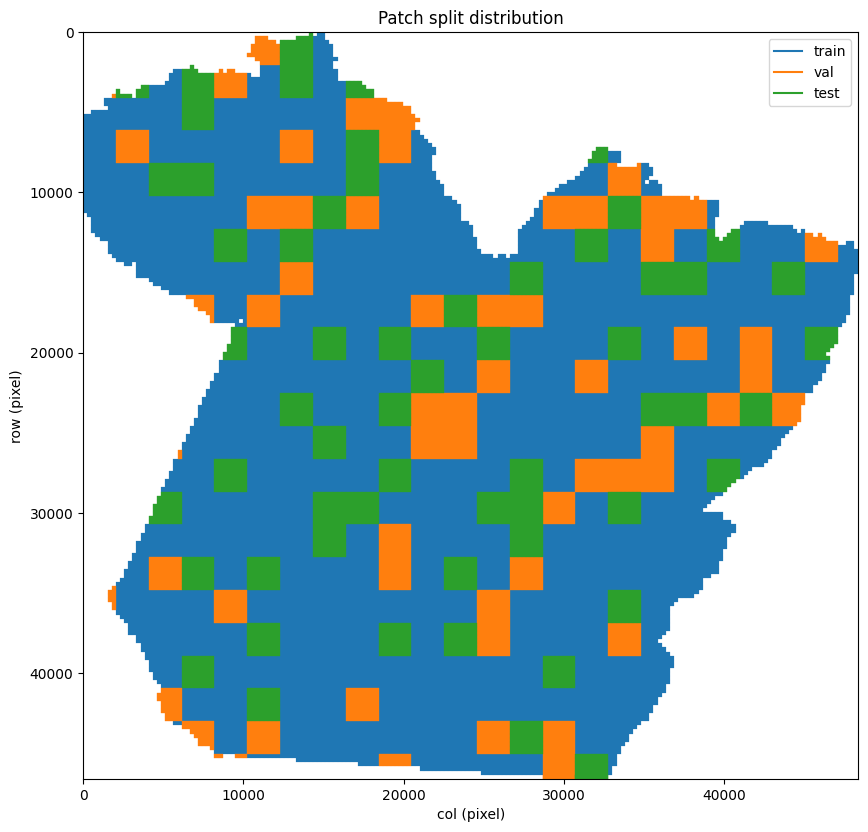

In [29]:
def add_patch_rectangles(ax, df, edgecolor, label, linewidth=0.2):
    rects = [
        Rectangle((r.col_off, r.row_off), r.width, r.height)
        for r in df.itertuples(index=False)
    ]
    pc = PatchCollection(
        rects,
        facecolor=edgecolor,      # outline-only
        edgecolor=edgecolor,
        linewidths=linewidth
    )
    ax.add_collection(pc)
    # Add a dummy handle for legend
    ax.plot([], [], color=edgecolor, label=label)

plt.figure(figsize=(10, 10))
ax = plt.gca()

add_patch_rectangles(ax, train_df, edgecolor="C0", label="train", linewidth=0.15)
add_patch_rectangles(ax, val_df,   edgecolor="C1", label="val",   linewidth=0.25)
add_patch_rectangles(ax, test_df,  edgecolor="C2", label="test",  linewidth=0.25)

# Set extent using raster size (optional but helps autoscale correctly)
with rasterio.open(img_path_full) as src:
    W, H = src.width, src.height

ax.set_xlim(0, W)
ax.set_ylim(H, 0)  # invert y-axis (image coordinates)
ax.set_aspect("equal", adjustable="box")

ax.legend()
ax.set_title("Patch split distribution")
ax.set_xlabel("col (pixel)")
ax.set_ylabel("row (pixel)")
plt.show()

### Plot Split Footprints: Zoomed ROI (Pixel Space)

ROI counts: 32 16 16


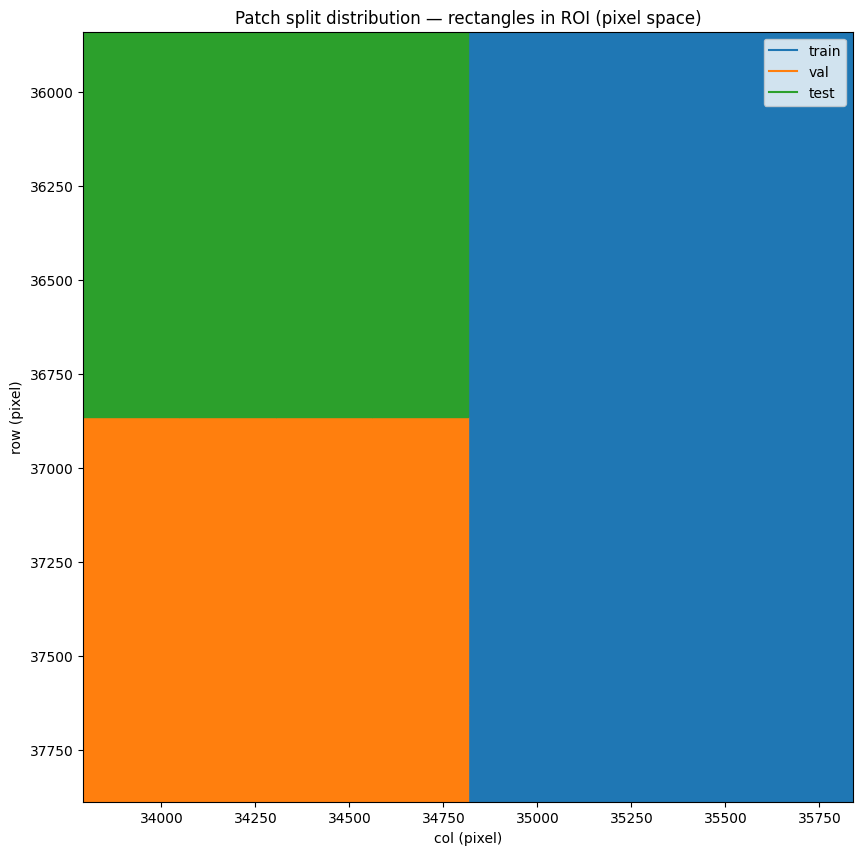

In [ ]:
def filter_roi(df, row0, col0, row1, col1):
    pr0 = df["row_off"].to_numpy()
    pc0 = df["col_off"].to_numpy()
    pr1 = pr0 + df["height"].to_numpy()
    pc1 = pc0 + df["width"].to_numpy()
    keep = (pr0 < row1) & (pr1 > row0) & (pc0 < col1) & (pc1 > col0)
    return df[keep]

# Example: ROI around this known patch top-left (adjust if you want)
roi_center_row = 36864
roi_center_col = 34816
roi_size = 2048

row0 = roi_center_row - roi_size//2
col0 = roi_center_col - roi_size//2
row1 = roi_center_row + roi_size//2
col1 = roi_center_col + roi_size//2

train_roi = filter_roi(train_df, row0, col0, row1, col1)
val_roi   = filter_roi(val_df,   row0, col0, row1, col1)
test_roi  = filter_roi(test_df,  row0, col0, row1, col1)

print("ROI counts:", len(train_roi), len(val_roi), len(test_roi))

plt.figure(figsize=(10, 10))
ax = plt.gca()

add_patch_rectangles(ax, train_roi, edgecolor="C0", label="train", linewidth=0.8)
add_patch_rectangles(ax, val_roi,   edgecolor="C1", label="val",   linewidth=1.0)
add_patch_rectangles(ax, test_roi,  edgecolor="C2", label="test",  linewidth=1.0)

ax.set_xlim(col0, col1)
ax.set_ylim(row1, row0)
ax.set_aspect("equal", adjustable="box")
ax.legend()
ax.set_title("Patch split distribution — rectangles in ROI (pixel space)")
ax.set_xlabel("col (pixel)")
ax.set_ylabel("row (pixel)")
plt.show()

### Plot Split Footprints: Map Coordinates (CRS)

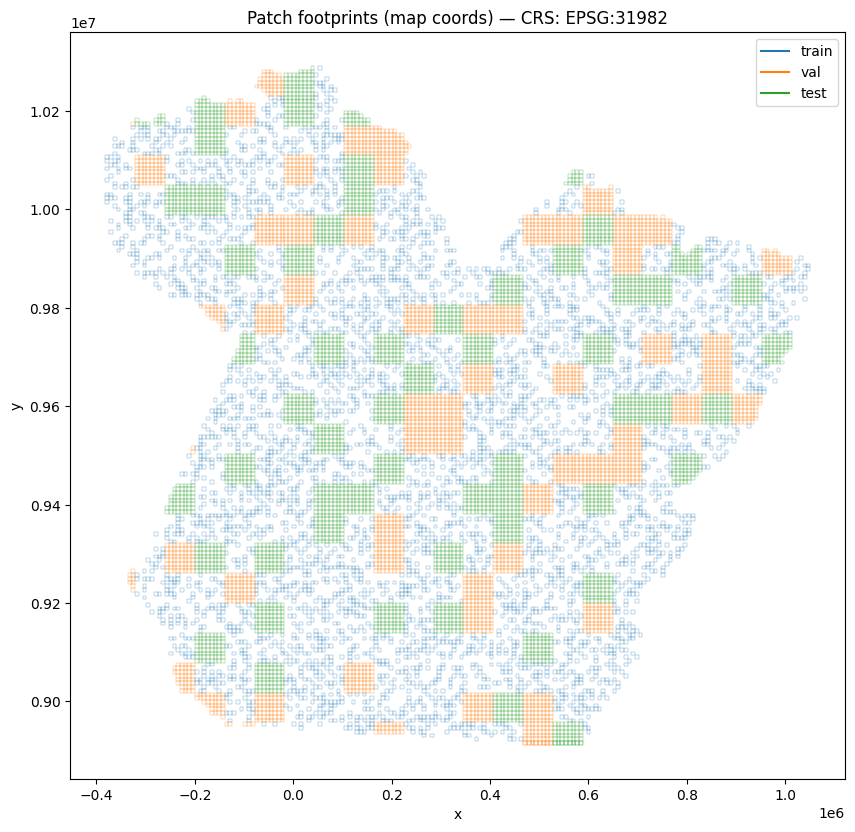

In [ ]:
def add_patch_polygons_world(ax, df, transform, edgecolor, label, linewidth=0.2):
    polys = []
    for r in df.itertuples(index=False):
        r0, c0 = r.row_off, r.col_off
        r1, c1 = r.row_off + r.height, r.col_off + r.width

        # four corners in world coords
        x_ul, y_ul = rasterio.transform.xy(transform, r0, c0, offset="ul")
        x_ur, y_ur = rasterio.transform.xy(transform, r0, c1, offset="ur")
        x_lr, y_lr = rasterio.transform.xy(transform, r1, c1, offset="lr")
        x_ll, y_ll = rasterio.transform.xy(transform, r1, c0, offset="ll")

        polys.append(Polygon([(x_ul,y_ul),(x_ur,y_ur),(x_lr,y_lr),(x_ll,y_ll)], closed=True))

    pc = PatchCollection(polys, facecolor="none", edgecolor=edgecolor, linewidths=linewidth)
    ax.add_collection(pc)
    ax.plot([], [], color=edgecolor, label=label)

with rasterio.open(img_path_full) as src:
    transform = src.transform
    crs = src.crs

plt.figure(figsize=(10, 10))
ax = plt.gca()

# If too many patches, do ROI or sample first (recommended)
add_patch_polygons_world(ax, train_df.sample(min(5000, len(train_df)), random_state=42), transform, "C0", "train", 0.2)
add_patch_polygons_world(ax, val_df.sample(min(5000, len(val_df)), random_state=42),     transform, "C1", "val",   0.2)
add_patch_polygons_world(ax, test_df.sample(min(5000, len(test_df)), random_state=42),   transform, "C2", "test",  0.2)

ax.autoscale()
ax.set_aspect("equal", adjustable="box")
ax.legend()
ax.set_title(f"Patch footprints (map coords) — CRS: {crs}")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

### Integrity Check: No Duplicate Patches Across Splits

In [ ]:
def make_keys(df):
    return set(zip(df.row_off, df.col_off, df.height, df.width))

train_k = make_keys(train_df)
val_k   = make_keys(val_df)
test_k  = make_keys(test_df)

print("Train ∩ Val :", len(train_k & val_k))
print("Train ∩ Test:", len(train_k & test_k))
print("Val ∩ Test  :", len(val_k & test_k))

Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0


### Integrity Check: No Overlap via Coverage Map (ROI)

Unique coverage values: [1]
Max coverage (should be 1): 1


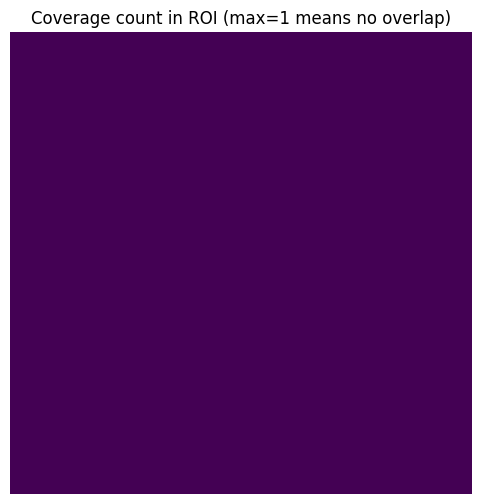

In [ ]:
def intersects_roi(df, roi):
    r0, c0, r1, c1 = roi
    pr0 = df["row_off"].to_numpy()
    pc0 = df["col_off"].to_numpy()
    pr1 = pr0 + df["height"].to_numpy()
    pc1 = pc0 + df["width"].to_numpy()
    return (pr0 < r1) & (pr1 > r0) & (pc0 < c1) & (pc1 > c0)

def coverage_map(df_roi, roi):
    r0, c0, r1, c1 = roi
    cov = np.zeros((r1-r0, c1-c0), dtype=np.uint8)
    for r in df_roi.itertuples(index=False):
        rr0 = max(r.row_off, r0) - r0
        cc0 = max(r.col_off, c0) - c0
        rr1 = min(r.row_off + r.height, r1) - r0
        cc1 = min(r.col_off + r.width, c1) - c0
        cov[rr0:rr1, cc0:cc1] += 1
    return cov

# pick an ROI (use the same centre you used for the ROI rectangle plot)
roi_center_row = 36864
roi_center_col = 34816
roi_size = 2048
roi = (roi_center_row - roi_size//2, roi_center_col - roi_size//2,
       roi_center_row + roi_size//2, roi_center_col + roi_size//2)

train_roi = train_df[intersects_roi(train_df, roi)]
val_roi   = val_df[intersects_roi(val_df, roi)]
test_roi  = test_df[intersects_roi(test_df, roi)]

cov = coverage_map(train_roi, roi) + coverage_map(val_roi, roi) + coverage_map(test_roi, roi)

print("Unique coverage values:", np.unique(cov))
print("Max coverage (should be 1):", cov.max())

plt.figure(figsize=(6,6))
plt.imshow(cov, interpolation="nearest")
plt.title("Coverage count in ROI (max=1 means no overlap)")
plt.axis("off")
plt.show()

### Plot Training Curves (Val Macro IoU and Train Loss)

Plots training curves from the exported history CSV to show convergence behaviour and confirm early stopping occurred near a plateau.

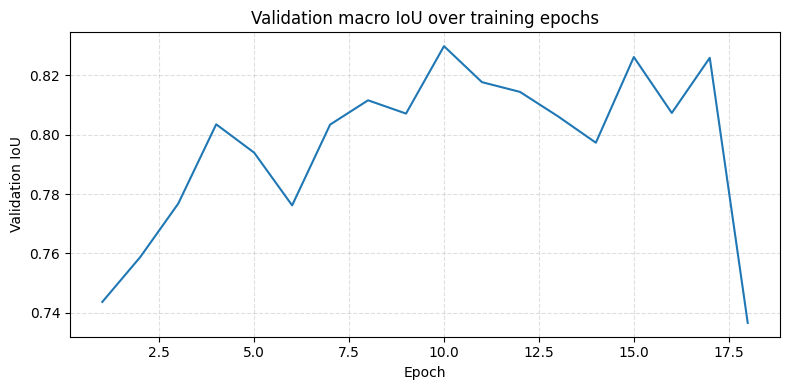

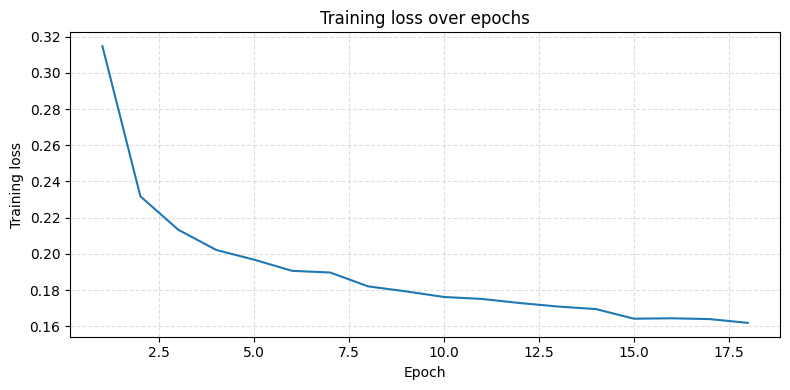

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Directories
split_dir = Path("../../data/outputs/splits/unet_resnet34_p256_b2048")
fig_dir = Path("../../data/outputs/baseline/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

# Load data
hist = pd.read_csv(split_dir / "final_train_history.csv")

# Validation IoU plot
plt.figure(figsize=(8, 4))
plt.plot(hist["epoch"], hist["val_macro_iou"])
plt.xlabel("Epoch")
plt.ylabel("Validation IoU")
plt.title("Validation macro IoU over training epochs")
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(fig_dir / "training_val_iou.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


# Training loss plot
plt.figure(figsize=(8, 4))
plt.plot(hist["epoch"], hist["train_loss"])
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training loss over epochs")
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(fig_dir / "training_loss.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

### Plot Final Performance Summary (Macro + Per-Class)

Creates meeting-friendly bar charts for macro metrics and per-class IoU (val vs test), with value labels printed above bars.

#### Plot Macro Metrics (Val vs Test)

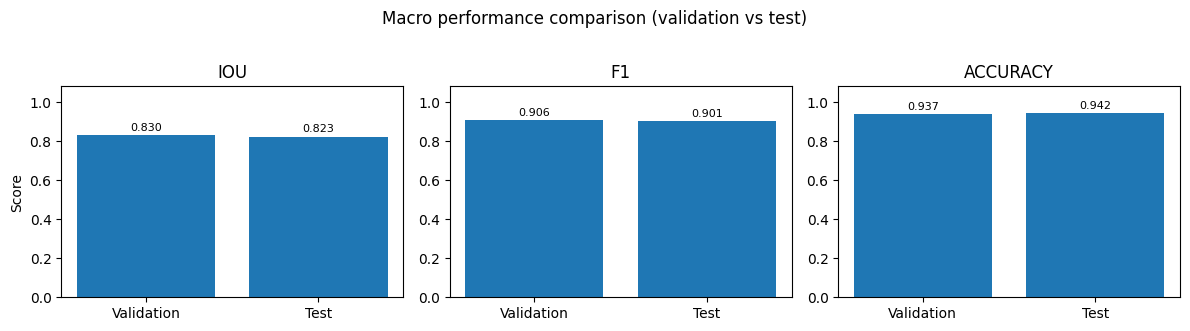

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def label_bars(ax, values, fmt="{:.3f}", pad=0.015):
    """
    pad is in data units, so with ylim 0–1.08, 0.015 is a safe gap.
    """
    for p, v in zip(ax.patches, values):
        ax.text(
            p.get_x() + p.get_width() / 2,
            v + pad,
            fmt.format(v),
            ha="center",
            va="bottom",
            fontsize=8,
            clip_on=False
        )

# Paths
split_dir = Path("../../data/outputs/splits/unet_resnet34_p256_b2048")
fig_dir = Path("../../data/outputs/baseline/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

# Load macro data
macro = pd.read_csv(split_dir / "final_macro_metrics.csv")
macro = macro[macro["class"] == "macro"].copy()
macro["split"] = macro["split"].replace({
    "val": "Validation",
    "test": "Test"
})
macro = macro.set_index("split").loc[["Validation", "Test"]].reset_index()

metrics = ["iou", "f1", "accuracy"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))

for ax, m in zip(axes, metrics):
    bars = ax.bar(macro["split"], macro[m])

    # fixed headroom for all three panels
    ax.set_ylim(0, 1.08)

    ax.set_title(m.upper())

    label_bars(ax, macro[m].values, fmt="{:.3f}", pad=0.015)

axes[0].set_ylabel("Score")

plt.suptitle("Macro performance comparison (validation vs test)", y=1.02)
plt.tight_layout()
plt.savefig(fig_dir / "macro_metrics_combined.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

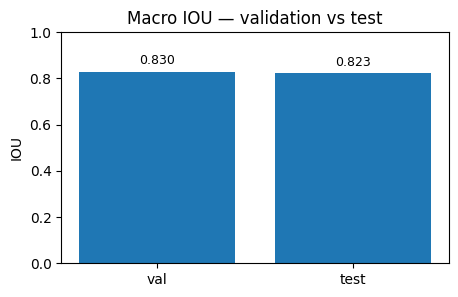

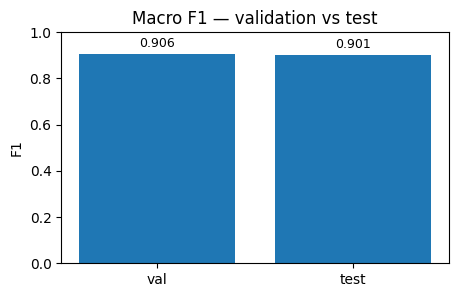

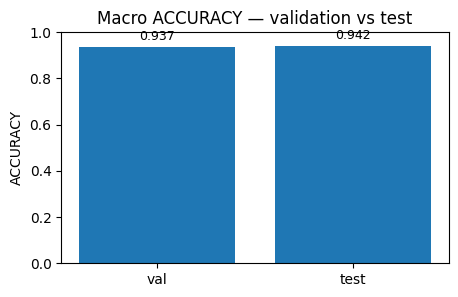

In [25]:
def label_bars(ax, fmt="{:.2f}"):
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            fmt.format(height),
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points",
        )

split_dir = Path("../../data/outputs/splits/unet_resnet34_p256_b2048")
macro = pd.read_csv(split_dir / "final_macro_metrics.csv")

macro = macro[macro["class"] == "macro"].copy()

metrics = ["iou", "f1", "accuracy"]

for m in metrics:
    fig, ax = plt.subplots(figsize=(5,3))
    bars = ax.bar(macro["split"], macro[m])
    ax.set_ylim(0, 1.0)
    ax.set_ylabel(m.upper())
    ax.set_title(f"Macro {m.upper()} — validation vs test")
    label_bars(ax, fmt="{:.3f}")
    plt.show()


#### Plot Per-Class IoU (Val and Test)

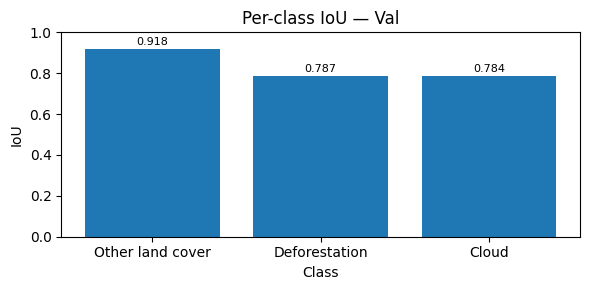

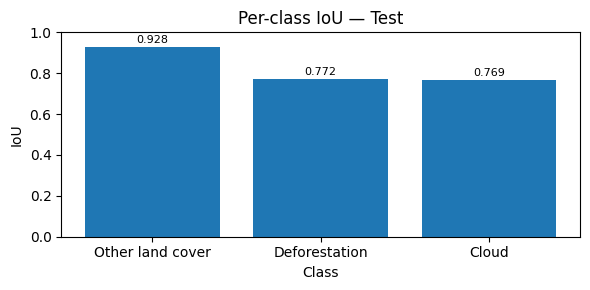

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Directory setup
split_dir = Path("../../data/outputs/splits/unet_resnet34_p256_b2048")
fig_dir = Path("../../data/outputs/baseline/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

# Load data
pc = pd.read_csv(split_dir / "final_per_class_metrics.csv")

# Map class IDs to names
class_map = {
    0: "Other land cover",
    1: "Deforestation",
    2: "Cloud"
}
pc["class"] = pc["class"].map(class_map)

# Plot and save
for split in ["val", "test"]:
    d = pc[pc["split"] == split].copy()

    fig, ax = plt.subplots(figsize=(6, 3))

    bars = ax.bar(d["class"], d["iou"])

    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Class")
    ax.set_ylabel("IoU")
    ax.set_title(f"Per-class IoU — {split.capitalize()}")

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

    # Improve layout
    plt.tight_layout()

    # Save figure
    filename = fig_dir / f"per_class_iou_{split}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()
    plt.close()

## Full Metrics
### Macro

In [38]:
pd.read_csv('../../data/outputs/splits/unet_resnet34_p256_b2048/final_macro_metrics.csv')

,split,class,precision,recall,f1,iou,accuracy
0,val,macro,0.897112,0.914876,0.905747,0.829794,0.936783
1,test,macro,0.902452,0.900499,0.901162,0.823061,0.942224


In [8]:
import pandas as pd

df_macro = pd.read_csv(
    "../../data/outputs/splits/unet_resnet34_p256_b2048/final_macro_metrics.csv"
)

df_macro = df_macro[df_macro["class"] == "macro"].copy()
df_macro["split"] = df_macro["split"].replace({
    "val": "Validation",
    "test": "Test"
})
df_macro = df_macro[["split", "accuracy", "f1", "iou"]]
df_macro.columns = ["Split", "Accuracy", "F1", "IoU"]

latex_macro = df_macro.to_latex(
    index=False,
    float_format="%.3f",
    column_format="lccc",
    escape=False
)

with open("../../data/outputs/baseline/tables/macro_results.tex", "w") as f:
    f.write(latex_macro)

### Per class

In [39]:
pd.read_csv('../../data/outputs/splits/unet_resnet34_p256_b2048/final_per_class_metrics.csv')

,split,class,precision,recall,f1,iou,support_pixels
0,val,0,0.958651,0.955534,0.957090,0.917711,154473207.0
1,val,1,0.878207,0.883958,0.881073,0.787426,53285084.0
2,val,2,0.854479,0.905135,0.879078,0.784245,2585066.0
3,test,0,0.955781,0.970009,0.962842,0.928347,175539716.0
4,test,1,0.895917,0.847889,0.871242,0.771858,50209216.0
5,test,2,0.855657,0.883598,0.869403,0.768978,2402190.0


In [9]:
import pandas as pd

df_pc = pd.read_csv(
    "../../data/outputs/splits/unet_resnet34_p256_b2048/final_per_class_metrics.csv"
)

df_pc = df_pc[df_pc["split"] == "test"].copy()

class_map = {
    0: "Other land cover",
    1: "Deforestation",
    2: "Cloud"
}
df_pc["class"] = df_pc["class"].map(class_map)

df_pc = df_pc[["class", "precision", "recall", "f1", "iou"]]
df_pc.columns = ["Class", "Precision", "Recall", "F1", "IoU"]

latex_pc = df_pc.to_latex(
    index=False,
    float_format="%.3f",
    column_format="lcccc",
    escape=False
)

with open("../../data/outputs/baseline/tables/class_results.tex", "w") as f:
    f.write(latex_pc)

## Notebook Summary

**1) Experiment setup (fixed conventions)**
- Defined input rasters (image + label), 6 Landsat bands (2–7) as model inputs, and 3 target classes
- Set consistent nodata / ignore_index = -9999
- Selected patching defaults (patch_size = 256, stride_train = 256, stride_infer = 128) and runtime settings (device, batching)

**2) Patch grid construction (Rasterio windows)**
- Built a deterministic patch index over the raster using rasterio windows
- Implemented edge-coverage logic to ensure border areas are not missed
- Filtered patches that contain only ignore_index labels (removes empty/invalid supervision)

**3) Spatial block split to reduce spatial leakage**
- Implemented a coarse block-based split (block_size tested) to separate train/val/test geographically
- Produced reproducible splits using a fixed seed = 42
- Exported patch lists and block IDs for full-raster runs (CSV)

**4) Train-only normalisation**
- Estimated per-band mean/std using a sample of TRAIN patches only
- Applied normalisation only on valid pixels (nodata set to 0 after normalisation)
- Saved final train mean/std arrays (.npy) for reproducibility

**5) Baseline study: patch size × block size (Optuna)**
- Compared spatial design choices across:
  - PATCH_SIZES = [128, 256, 512]
  - BLOCK_SIZES = [2048, 4096]
- For each design: trained U-Net baseline and recorded best validation mean IoU
- Saved comparison table to CSV:

**6) Optuna tuning (augmentation + class weighting + early stopping)**
- Extended dataset with lightweight augmentation:
  - random flips, rotations, and additive Gaussian noise (valid pixels only)
- Estimated class frequencies and implemented beta-controlled inverse-frequency loss weighting
- Ran a two-stage Optuna process for the fixed spatial design (p256, b2048):
  - Stage A: broad search with pruning and limited epochs. Saved trials CSV
  - Stage B: confirmation of top-K configs. Saved confirmation CSV and winner parameters

**7) Final training on full rasters**
- Rebuilt patch grid and block splits on the full rasters
- Exported reusable split CSVs (train/val/test) and saved train-only mean/std
- Trained final U-Net using the best Optuna hyperparameters with early stopping
- Saved:
  - best checkpoint: final_model_best.pt
  - training history: final_train_history.csv

**8) Final evaluation and exports (validation and test)**
- Evaluated best checkpoint on val and test
- Computed confusion-matrix derived metrics:
  - per-class: precision / recall / F1 / IoU (with pixel support)
  - macro: precision / recall / F1 / IoU and accuracy
- Exported:
  - final_per_class_metrics.csv
  - final_macro_metrics.csv

**9) Diagnostics and meeting-ready plots**
- Visualised spatial distribution of train/val/test patches:
- Ran integrity checks:
  - no duplicate patches across splits
  - ROI coverage check to detect overlap
- Plotted:
  - training curves (val macro IoU, train loss)
  - macro metric bar charts (val vs test)
  - per-class IoU bar charts (val and test)

## Selected Experiment Values

* **Patch size:** 256
* **Stride (train):** 256
* **Block size:** 2048
* **Split ratios (train/val/test):** 0.70 / 0.15 / 0.15
* **Seed:** 42
* **Encoder:** ResNet34
* **Input channels:** 6
* **Nodata / ignore index:** -9999
* **Normalisation:** per-band mean/std (train-only)
* **Max epochs:** 50
* **Early stopping patience:** 8
* **Best LR:** 0.000116
* **Best weight decay:** 0.000478
* **Best batch size:** 4
* **Aug prob / noise std:** 0.230711 / 0.074686
* **Loss weighting beta:** 0.205623

## Executive Summary

This notebook implements a baseline for patch-based land-cover segmentation using a U-Net with a ResNet34 encoder on a Landsat 8/9 map and PRODES label.

A spatially aware training pipeline was developed, including deterministic patch generation, block-based train/validation/test splitting to reduce spatial leakage, and train-only normalisation. Multiple spatial designs (patch size × block size) were evaluated to select a stable baseline configuration.

Hyperparameters were tuned using a two-stage Optuna procedure with early stopping, lightweight data augmentation, and beta-controlled class-weighted loss. The best configuration was confirmed and fixed for final training.

The final model was trained on the full rasters with reproducible splits, and evaluated on both validation and test sets using confusion-matrix-derived metrics (IoU, F1, accuracy).

This baseline establishes a controlled reference point for comparing data-centric improvements.